# Application Script [06.05.2026]

# SCRIPT - 5/5/2026 - removal numeric_rank

## 🤖 Device Cluster — Model Application Script
> Suffix-only model + numeric convention features + KNN OOD distance penalty
> **Updated:** 05/05/2026

---

## 🔀 Inference Design

| Gate | Type | Trigger | Behaviour |
|------|------|---------|-----------|
| **Gate 1** — Customer | 🔴 HARD BLOCK | Missing or unseen customer | Rejected entirely — prediction does **not** run |
| **Gate 2** — Numeric Width | 🟡 SOFT WARNING | Width outside training range | `FORMAT_WARNING` column populated — prediction **still runs** |
| **KNN OOD Penalty** | 🔵 POST-HOC | Far from training distribution | Confidence score adjusted downward |

---

## 📉 KNN OOD Penalty Logic

| Distance from Training Data | Penalty Applied | Confidence Result | Output Label |
|-----------------------------|-----------------|-------------------|--------------|
| Close to training distribution | None / Low | Stays high | Predicted cluster |
| Far from training distribution | Heavy | Drops below 50% | `UNKNOWN` |

> ⚠️ `UNKNOWN` does **not** mean the prediction didn't run.
> It means the model ran but was **not confident enough** to surface a result.

In [4]:
import pandas as pd
import numpy as np # numpy
import re
import pickle
import os
import warnings
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

warnings.filterwarnings('ignore')


# ============================================================
# 📂 PATHS & CONSTANTS
# ============================================================

MODEL_DIR           = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
OUTPUT_DIR          = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\output_prediction"
UNKNOWN_THRESHOLD   = 0.60 

# ============================================================
# 🔐 SafeLabelEncoder
# ============================================================

class SafeLabelEncoder:
    """
    A LabelEncoder that:
      - Adds an '__UNKNOWN__' class during fit.
      - Returns the index of '__UNKNOWN__' for any unseen
        label during transform, instead of crashing.
      - Provides is_known(values) for explicit gate checks.
    """

    UNKNOWN_LABEL = "__UNKNOWN__"

    def __init__(self):
        self._le      = LabelEncoder()
        self.classes_ = None

    def fit(self, y):
        labels = list(pd.Series(y).astype(str).unique())
        if self.UNKNOWN_LABEL not in labels:
            labels = [self.UNKNOWN_LABEL] + labels
        self._le.fit(labels)
        self.classes_ = self._le.classes_
        return self

    def transform(self, y):
        y_str  = pd.Series(y).astype(str)
        known  = set(self.classes_)
        y_safe = y_str.where(y_str.isin(known), other=self.UNKNOWN_LABEL)
        return self._le.transform(y_safe)

    def fit_transform(self, y):
        return self.fit(y).transform(y)

    def inverse_transform(self, y):
        return self._le.inverse_transform(y)

    def is_known(self, values):
        """Return a boolean Series: True if value is known (not __UNKNOWN__)."""
        known = set(self.classes_) - {self.UNKNOWN_LABEL}
        return pd.Series(values).astype(str).isin(known)

    def real_classes(self):
        """Return classes excluding the __UNKNOWN__ sentinel."""
        return [c for c in self.classes_ if c != self.UNKNOWN_LABEL]


# ============================================================
# 🔧 FEATURE ENGINEERING HELPERS
# ============================================================

def extract_numeric_block(device_id):
    """First number as integer — strips leading zeros.
    e.g. 'FF051' → 51,  'LL0000000021' → 21
    """
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

def extract_numeric_string(device_id):
    """Raw digit string preserving leading zeros.
    e.g. 'FF051' → '051',  'LL0000000021' → '0000000021'
    """
    match = re.search(r'\d+', str(device_id))
    return match.group() if match else ''

def extract_suffix_letters(device_id):
    """Letters immediately after the trailing number.
    e.g. 'M051A' → 'A',  'FCV001' → ''
    """
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

def extract_suffix_full(device_id):
    """Everything after the trailing number.
    e.g. 'M051A' → 'A',  'TE051' → ''
    """
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

def extract_numeric_suffix_shape(device_id):
    """Shape from first digit onwards — strips leading equipment-type letters.
    e.g. V01BP1 -> DDLLD,  HL510 -> DDD,  PT500A -> DDDL
    """
    match = re.search(r'\d.*', str(device_id))
    if not match:
        return 'NODIGIT'
    return ''.join('L' if c.isalpha() else 'D' for c in match.group())


# ============================================================
# 📦 LOAD PIPELINE
# ============================================================

def load_pipeline(model_dir: str) -> dict:
    print("=" * 80)
    print("📦 LOADING SAVED PIPELINE")
    print("=" * 80)

    with open(os.path.join(model_dir, "model_section.pkl"),   "rb") as f: model_section   = pickle.load(f)
    with open(os.path.join(model_dir, "model_cluster.pkl"),   "rb") as f: model_cluster   = pickle.load(f)
    with open(os.path.join(model_dir, "pipeline_config.pkl"), "rb") as f: pipeline_config = pickle.load(f)

    known_customers  = pipeline_config['known_customers']

    # ── Numeric width knowledge (soft warning only) ───────────
    known_num_widths = pipeline_config.get('known_num_widths', None)
    reliable_widths  = pipeline_config.get('reliable_widths',  None)
    max_num_width    = pipeline_config.get('max_num_width',    None)

    # ── KNN OOD distance scorer ───────────────────────────────
    ood_scaler    = pipeline_config.get('ood_scaler',             None)
    le_customer   = pipeline_config.get('le_customer',            None)
    ood_knn       = pipeline_config.get('ood_knn',                None)
    ood_features  = pipeline_config.get('ood_features',           None)
    ood_threshold = pipeline_config.get('ood_distance_threshold', None)

    print("   ✅ model_section.pkl     loaded")
    print("   ✅ model_cluster.pkl     loaded")
    print("   ✅ pipeline_config.pkl   loaded")

    print(f"\n   Known customers  : {sorted(known_customers)}")
    print(f"   Section classes  : {pipeline_config['le_section'].real_classes()}")
    print(f"   Cluster classes  : {pipeline_config['le_cluster'].real_classes()}")
    print(f"   Section features : {pipeline_config['section_features']}")
    print(f"   Cluster features : {pipeline_config['cluster_features']}")

    # ── Numeric width gate status ─────────────────────────────
    if known_num_widths is not None:
        print(f"\n   Numeric width knowledge (soft warning):")
        print(f"      Known widths    : {sorted(known_num_widths)}")
        print(f"      Reliable widths : {sorted(reliable_widths)}")
        print(f"      Max width       : {max_num_width} digits")
    else:
        print("\n   ⚠ Numeric width knowledge not found — retrain to enable soft warning")

    # ── KNN OOD scorer status ─────────────────────────────────
    if ood_knn is not None:
        print(f"\n   KNN OOD distance scorer:")
        print(f"      OOD features    : {ood_features}")
        print(f"      OOD threshold   : {ood_threshold:.4f}")
        print(f"      Penalty formula : conf / (1 + distance / threshold)  [inverse distance weighting]")
    else:
        print("\n   ⚠ KNN OOD scorer not found — retrain to enable confidence penalty")


    if le_customer is not None:
        print(f"   Known customers  : {le_customer.real_classes()}")
    else:
        print("   ⚠ le_customer not found — retrain to enable customer encoding")

    return {
        "model_section"   : model_section,
        "model_cluster"   : model_cluster,
        "config"          : pipeline_config,
        "known_customers" : known_customers,
        "known_num_widths": known_num_widths,
        "reliable_widths" : reliable_widths,
        "max_num_width"   : max_num_width,
        "ood_scaler"      : ood_scaler,
        "ood_knn"         : ood_knn,
        "ood_features"    : ood_features,
        "ood_threshold"   : ood_threshold,
        "le_customer"     : le_customer,
    }


# ============================================================
# 🛡️  GUARD — CUSTOMER GATE + NUMERIC WIDTH WARNING
# ============================================================

def check_entities(df: pd.DataFrame, pipeline: dict) -> tuple[pd.Series, pd.Series]:
    """
    Returns two Series:
    rejection_reasons : HARD BLOCK
        Triggered by missing or unseen CUSTOMER only.
        Row is excluded from inference entirely.
    format_warnings : SOFT WARNING
        Triggered by unusual numeric field width.
        Prediction STILL RUNS — user is informed via FORMAT_WARNING column.
        KNN penalty will handle confidence reduction.
    Why split into two?
        Customer is a data integrity problem — unknown customer means
        we cannot trust any prediction at all.
        Numeric width is a format uncertainty — the model may still
        partially predict correctly, KNN penalty expresses the doubt.
    """

    known_customers = pipeline["known_customers"]
    reliable_widths = pipeline.get("reliable_widths", None)
    max_num_width   = pipeline.get("max_num_width",   None)

    rejections = []
    warnings_  = []

    for _, row in df.iterrows():
        row_reject = []
        row_warn   = []

        # ── HARD BLOCK: Device ID ─────────────────────────────
        dev = str(row.get('DEVICE_ID', '')).strip()
        if not dev or dev.upper() in ('', 'NAN', 'NONE'):
            row_reject.append("missing DEVICE_ID")

        # ── HARD BLOCK: Customer ──────────────────────────────
        cust = str(row.get('CUSTOMER', '')).strip()
        if not cust or cust.upper() in ('', 'NAN', 'NONE'):
            row_reject.append("missing CUSTOMER")
        elif cust not in known_customers:
            row_reject.append(
                f"unseen CUSTOMER '{cust}' — Please assign manually"
            )

        # ── SOFT WARNING: Numeric width ───────────────────────
        # Does NOT block — prediction still runs.
        # Informs the user that the numeric field format is unusual
        # so confidence scores should be treated with extra caution.
        # KNN penalty will reduce the confidence score accordingly.
        if reliable_widths is not None and max_num_width is not None:
            numeric_str = extract_numeric_string(str(row.get('DEVICE_ID', '')))
            if numeric_str:
                width = len(numeric_str)
                if width > max_num_width:
                    row_warn.append(
                        f"unusual format — numeric field width {width} digits "
                        f"exceeds training maximum of {max_num_width} digits "
                        f"(confidence penalised by KNN scorer)"
                    )
                elif width not in reliable_widths:
                    row_warn.append(
                        f"unusual format — numeric field width {width} digits "
                        f"is rare in training data, reliable widths: "
                        f"{sorted(reliable_widths)} digits "
                        f"(confidence penalised by KNN scorer)"
                    )

        rejections.append("; ".join(row_reject))
        warnings_.append("; ".join(row_warn))

    return (
        pd.Series(rejections, index=df.index),
        pd.Series(warnings_,  index=df.index),
    )


# ============================================================
# 🔧 BUILD FEATURES
# ============================================================

def build_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Mirrors training feature engineering exactly.

    Includes:
      - Numeric block raw + convention fingerprint
        (count_num_digit, leading_zero_count,
         count_num_remove_zero, numeric_remove_zero)
      - Suffix features + encoding

    Excluded:
      - Prefix features
      - Customer / project encoders
      - numeric_block_rank (removed — no project context at inference
        and not used in training anymore)
    """
    le_suffix_lt    = config['le_suffix_letter']
    le_suffix_last  = config['le_suffix_last']
    le_customer     = config['le_customer']
    le_shape        = config['le_shape']

    df = df.copy().reset_index(drop=True)

    # ── Numeric block: raw ────────────────────────────────────
    df['numeric_block']        = df['DEVICE_ID'].apply(extract_numeric_block)
    df['device_suffix_letter'] = df['DEVICE_ID'].apply(extract_suffix_letters)
    df['suffix_full']          = df['DEVICE_ID'].apply(extract_suffix_full)
    df['device_id_length']     = df['DEVICE_ID'].astype(str).str.len()
    df['has_suffix_letter']    = (df['device_suffix_letter'] != '').astype(int)
    df['has_numeric']          = (df['numeric_block'] != -1).astype(int)

    # ── Numeric block: convention fingerprint ─────────────────
    _numeric_raw_str            = df['DEVICE_ID'].apply(extract_numeric_string)
    df['count_num_digit']       = _numeric_raw_str.str.len()
    df['numeric_remove_zero']   = df['numeric_block']
    df['count_num_remove_zero'] = df['numeric_remove_zero'].apply(
                                      lambda x: len(str(x)) if x != -1 else 0)
    df['leading_zero_count']    = df['count_num_digit'] - df['count_num_remove_zero']

    # ── Advanced suffix features ──────────────────────────────
    df['suffix_length']          = df['suffix_full'].astype(str).str.len()
    df['suffix_has_digit']       = df['suffix_full'].astype(str).str.contains(r'\d',       regex=True).astype(int)
    df['suffix_has_letter']      = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
    df['suffix_has_decimal']     = df['suffix_full'].astype(str).str.contains(r'\.',        regex=True).astype(int)
    df['suffix_digit_count']     = df['suffix_full'].astype(str).str.count(r'\d')
    df['suffix_letter_count']    = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')

    df['numeric_suffix_shape'] = df['DEVICE_ID'].apply(extract_numeric_suffix_shape)
    df['shape_enc']            = le_shape.transform(df['numeric_suffix_shape'])

    # Safe lambda — avoids str[0] crash on empty suffix
    df['suffix_starts_with_digit'] = df['suffix_full'].apply(
        lambda s: 1 if len(str(s)) > 0 and str(s)[0].isdigit() else 0)
    df['suffix_last_char']         = df['suffix_full'].apply(
        lambda s: str(s)[-1] if len(str(s)) > 0 else '')
    df['suffix_last_char_is_letter'] = df['suffix_last_char'].apply(
        lambda c: 1 if isinstance(c, str) and c.isalpha() else 0)
    df['suffix_last_char_is_digit']  = df['suffix_last_char'].apply(
        lambda c: 1 if isinstance(c, str) and c.isdigit() else 0)

    # ── Equipment ID features ─────────────────────────────────
    df['equip_id_length']      = df['DEVICE_ID'].astype(str).str.len()
    df['equip_id_digit_count'] = df['DEVICE_ID'].astype(str).str.count(r'\d')

    # ── Suffix encoding ───────────────────────────────────────
    df['suffix_letter_enc']    = le_suffix_lt.transform(df['device_suffix_letter'])
    df['suffix_last_char_enc'] = le_suffix_last.transform(df['suffix_last_char'])
    df['customer_enc']         = le_customer.transform(df['CUSTOMER'])

    return df


# ============================================================
# 📐 KNN OOD CONFIDENCE PENALTY
# ============================================================

def apply_ood_penalty(conf_raw: np.ndarray,
                      df_feat: pd.DataFrame,
                      pipeline: dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Penalise XGBoost confidence scores based on distance from the
    training distribution in feature space.

    WHY:
        XGBoost silently routes OOD inputs to the nearest leaf and
        returns whatever confidence was stored there — often 90%+.
        This penalty corrects that by measuring how far the input
        is from anything the model actually trained on.

    HOW:
        1. Scale inference features using the saved StandardScaler
        2. Compute distance to 5 nearest training neighbours (KNN)
        3. Adjust confidence using inverse distance weighting

    Penalty formula:
        adjusted = conf_raw / (1 + avg_distance / threshold)
        - distance = 0          → adjusted = conf_raw        (unchanged)
        - distance = threshold  → adjusted = conf_raw / 2    (50% reduction)
        - distance >> threshold → adjusted approaches 0      (no floor/cap needed)

    Parameters
    ----------
    conf_raw  : raw confidence array from model.predict_proba().max()
    df_feat   : feature DataFrame from build_features()
    pipeline  : loaded pipeline dict from load_pipeline()

    Returns
    -------
    adjusted_conf : penalised confidence array (same shape)
    distances     : raw KNN distances (for debug/logging)
    """
    ood_scaler    = pipeline.get("ood_scaler",    None)
    ood_knn       = pipeline.get("ood_knn",       None)
    ood_features  = pipeline.get("ood_features",  None)
    ood_threshold = pipeline.get("ood_threshold", None)

    
    # Guard: threshold can be 0 if training data was perfectly clustered
    if any(v is None for v in [ood_scaler, ood_knn, ood_features, ood_threshold]):
        return conf_raw, np.zeros(len(conf_raw))

    if ood_threshold <= 0:
        return conf_raw, np.zeros(len(conf_raw))  # no penalty, return original

    # ── Scale OOD features ────────────────────────────────────
    X_ood = (
        df_feat[ood_features]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
    )
    X_ood_scaled = ood_scaler.transform(X_ood)

    # ── Distance to 5 nearest training neighbours ─────────────
    distances, _ = ood_knn.kneighbors(X_ood_scaled)
    avg_dist      = distances.mean(axis=1)


    # - distance <= threshold → ratio = 0  → adjusted = conf_raw  (no penalty)
    # - distance = 2×threshold → ratio = 1 → adjusted = conf_raw / 2
    # - distance >> threshold  → adjusted approaches 0
    ratio = np.maximum(0, avg_dist - ood_threshold) / ood_threshold
    adjusted = conf_raw / (1 + ratio)


    return adjusted, avg_dist


# ============================================================
# 🚀 PREDICT
# ============================================================

def predict(records: list[dict], pipeline: dict,
            threshold: float = UNKNOWN_THRESHOLD) -> pd.DataFrame:
    """
    Run two-stage (section → cluster) inference on a list of device records.

    Flow:
        1. Normalise input
        2. Customer hard gate (block if unseen/missing)
        3. Numeric width soft warning (populate FORMAT_WARNING, still predict)
        4. Build features
        5. Stage 1 — Section model
        6. Apply KNN OOD penalty to section confidence
        7. Chain — inject predicted section
        8. Stage 2 — Cluster model
        9. Apply KNN OOD penalty to cluster confidence
       10. Apply threshold → UNKNOWN if below 50%
       11. Assemble result DataFrame

    Parameters
    ----------
    records   : list of dicts with keys 'device_id' and 'customer'
    pipeline  : loaded pipeline dict from load_pipeline()
    threshold : minimum confidence to emit a label (else 'UNKNOWN')

    Returns
    -------
    pd.DataFrame columns:
        DEVICE_ID, CUSTOMER,
        PREDICTED_SECTION, SECTION_CONFIDENCE,
        PREDICTED_CLUSTER,  CLUSTER_CONFIDENCE,
        REJECTION_REASON, FORMAT_WARNING
    """
    config        = pipeline["config"]
    model_section = pipeline["model_section"]
    model_cluster = pipeline["model_cluster"]
    le_section    = config["le_section"]
    le_cluster    = config["le_cluster"]

    section_features = config["section_features"]
    cluster_features = config["cluster_features"]

    # ── Normalise input ───────────────────────────────────────
    base_df         = pd.DataFrame(records)
    base_df.columns = base_df.columns.str.upper()
    if "PROJECT" not in base_df.columns:
        base_df["PROJECT"] = ""

    # ── Gate: customer (hard) + numeric width (soft warning) ──
    rejection_reasons, format_warnings = check_entities(base_df, pipeline)
    eligible_mask = rejection_reasons == ""   # only hard block excludes

    # ── Pre-fill outputs ──────────────────────────────────────
    pred_section = ["UNKNOWN"] * len(base_df)
    sec_conf     = [None]      * len(base_df)
    pred_cluster = ["UNKNOWN"] * len(base_df)
    clu_conf     = [None]      * len(base_df)

    # ── Inference on eligible rows ────────────────────────────
    if eligible_mask.any():
        elig_idx = base_df.index[eligible_mask].tolist()
        df_elig  = base_df.loc[elig_idx].copy()

        df_feat = build_features(df_elig, config)

        X_sec = (
            df_feat[section_features]
            .apply(pd.to_numeric, errors='coerce')
            .fillna(0)
        )

        # ── Stage 1 — Section ─────────────────────────────────
        sec_proba_raw = model_section.predict_proba(X_sec)
        sec_pred_enc  = np.argmax(sec_proba_raw, axis=1)
        sec_conf_raw  = sec_proba_raw.max(axis=1)


        # ── Debug: full probability distribution per device ───
        section_classes = le_section.classes_
        proba_df = pd.DataFrame(sec_proba_raw * 100, columns=section_classes)
        proba_df.insert(0, "DEVICE_ID", df_elig["DEVICE_ID"].values)
        proba_df.insert(1, "CUSTOMER", df_elig["CUSTOMER"].values)
        print("\n📊 SECTION RAW PROBABILITIES (per device):")
        print(proba_df.to_string(index=False, float_format=lambda x: f"{x:.2f}%"))

        # ── Apply KNN OOD penalty — Section ───────────────────
        # Reduces confidence for devices far from training distribution
        sec_conf_adj, sec_distances = apply_ood_penalty(
            sec_conf_raw, df_feat, pipeline
        )

        sec_decoded = le_section.inverse_transform(sec_pred_enc)
        sec_decoded = np.where(
            (sec_decoded == SafeLabelEncoder.UNKNOWN_LABEL) |
            (sec_decoded == '__OOD__'),
            "UNKNOWN", sec_decoded
        )

        # ── Chain — inject predicted section ──────────────────
        X_clu = (
            df_feat[[f for f in cluster_features if f != "predicted_section"]]
            .apply(pd.to_numeric, errors='coerce')
            .fillna(0)
            .copy()
        )
        X_clu["predicted_section"] = sec_pred_enc
        X_clu = X_clu[cluster_features]

        # ── Stage 2 — Cluster ─────────────────────────────────
        clu_proba_raw = model_cluster.predict_proba(X_clu)
        clu_pred_enc  = np.argmax(clu_proba_raw, axis=1)
        clu_conf_raw  = clu_proba_raw.max(axis=1)

        cluster_classes = le_cluster.classes_
        clu_proba_df = pd.DataFrame(clu_proba_raw * 100, columns=cluster_classes)
        clu_proba_df.insert(0, "DEVICE_ID", df_elig["DEVICE_ID"].values)
        clu_proba_df.insert(1, "CUSTOMER", df_elig["CUSTOMER"].values)
        print("\n📊 CLUSTER RAW PROBABILITIES (per device):")
        print(clu_proba_df.to_string(index=False, float_format=lambda x: f"{x:.2f}%"))


        # ── Apply KNN OOD penalty — Cluster ───────────────────
        clu_conf_adj, clu_distances = apply_ood_penalty(
            clu_conf_raw, df_feat, pipeline
        )

        clu_decoded = le_cluster.inverse_transform(clu_pred_enc)
        clu_decoded = np.where(
            (clu_decoded == SafeLabelEncoder.UNKNOWN_LABEL) |
            (clu_decoded == '__OOD__'),
            "UNKNOWN", clu_decoded
        )

        # ── Apply threshold on ADJUSTED confidence ─────────────
        # UNKNOWN means "model ran but not confident enough"
        # not "model was blocked"
        sec_final = np.where(sec_conf_adj >= threshold, sec_decoded, "UNKNOWN")
        clu_final = np.where(clu_conf_adj >= threshold, clu_decoded, "UNKNOWN")

        for i, orig_idx in enumerate(elig_idx):
            pred_section[orig_idx] = sec_final[i]
            sec_conf[orig_idx]     = round(float(sec_conf_adj[i]) * 100, 2)
            pred_cluster[orig_idx] = clu_final[i]
            clu_conf[orig_idx]     = round(float(clu_conf_adj[i]) * 100, 2)

    # ── Assemble result ───────────────────────────────────────
    result = base_df[["DEVICE_ID", "CUSTOMER", "PROJECT"]].copy()
    result["PREDICTED_SECTION"]  = pred_section
    result["SECTION_CONFIDENCE"] = sec_conf
    result["PREDICTED_CLUSTER"]  = pred_cluster
    result["CLUSTER_CONFIDENCE"] = clu_conf
    result["REJECTION_REASON"]   = rejection_reasons.values
    result["FORMAT_WARNING"]     = format_warnings.values

    return result


# ============================================================
# 🖨️  PRETTY PRINT RESULTS
# ============================================================

def print_results(result: pd.DataFrame):
    print("\n" + "=" * 80)
    print("📊 PREDICTION RESULTS")
    print("=" * 80)

    for _, row in result.iterrows():
        rejected = bool(row["REJECTION_REASON"])
        warned   = bool(row["FORMAT_WARNING"])

        print(f"\n   Device   : {row['DEVICE_ID']}")
        print(f"   Customer : {row['CUSTOMER']}")

        if rejected:
            # Hard blocked — model never ran
            print(f"   🚫 Blocked. {row['REJECTION_REASON']}")
            print(f"   ⛔ Section : {'UNKNOWN':20s}")
            print(f"   ⛔ Cluster : {'UNKNOWN':20s}")
        else:
            # Soft warning — model ran, KNN penalised confidence
            if warned:
                print(f"   ⚠ FORMAT WARNING — {row['FORMAT_WARNING']}")

            sec_unk      = row["PREDICTED_SECTION"] == "UNKNOWN"
            clu_unk      = row["PREDICTED_CLUSTER"]  == "UNKNOWN"
            sec_icon     = "⚠" if sec_unk else "✅"
            clu_icon     = "⚠" if clu_unk else "✅"
            sec_conf_str = f"{row['SECTION_CONFIDENCE']:.1f}%" if row["SECTION_CONFIDENCE"] is not None else "N/A"
            clu_conf_str = f"{row['CLUSTER_CONFIDENCE']:.1f}%" if row["CLUSTER_CONFIDENCE"] is not None else "N/A"

            print(f"   {sec_icon} Section : {row['PREDICTED_SECTION']:20s}  (confidence: {sec_conf_str})")
            print(f"   {clu_icon} Cluster : {row['PREDICTED_CLUSTER']:20s}  (confidence: {clu_conf_str})")

            # Explain UNKNOWN if prediction ran but fell below threshold
            if sec_unk and not warned:
                print(f"      ↳ below confidence threshold ({UNKNOWN_THRESHOLD*100:.0f}%)")
            if sec_unk and warned:
                print(f"      ↳ KNN penalty reduced confidence below threshold ({UNKNOWN_THRESHOLD*100:.0f}%)")
            if clu_unk and not warned:
                print(f"      ↳ below confidence threshold ({UNKNOWN_THRESHOLD*100:.0f}%)")
            if clu_unk and warned:
                print(f"      ↳ KNN penalty reduced confidence below threshold ({UNKNOWN_THRESHOLD*100:.0f}%)")

        print(f"   {'-' * 60}")

    total     = len(result)
    blocked   = (result["REJECTION_REASON"] != "").sum()
    warned    = ((result["FORMAT_WARNING"] != "") & (result["REJECTION_REASON"] == "")).sum()
    evaluated = total - blocked
    unk_sec   = ((result["PREDICTED_SECTION"] == "UNKNOWN") & (result["REJECTION_REASON"] == "")).sum()
    unk_clu   = ((result["PREDICTED_CLUSTER"]  == "UNKNOWN") & (result["REJECTION_REASON"] == "")).sum()

    print(f"\n{'=' * 80}")
    print(f"   Total records             : {total}")
    print(f"   Evaluated by model        : {evaluated}   |   Blocked (customer): {blocked}")
    if warned:
        print(f"   Format warnings (ran+KNN) : {warned}")
    if unk_sec or unk_clu:
        print(f"   Low-confidence UNKNOWN    → Section: {unk_sec}   |   Cluster: {unk_clu}")
    print(f"   Confidence threshold used : {UNKNOWN_THRESHOLD * 100:.0f}%")
    print("=" * 80)

# ============================================================
# 📋 EXPORT UNKNOWNS FOR MANUAL ASSIGNMENT
# ============================================================

def export_unknown_for_review(result: pd.DataFrame, output_dir: str) -> str:
    """
    Export all UNKNOWN rows to Excel for manual assignment.

    Covers both:
      Type A — LOW_CONFIDENCE : model ran but confidence below threshold
      Type B — BLOCKED        : hard-blocked (unknown/missing customer or device)

    User opens the file, fills ASSIGNED_SECTION and ASSIGNED_CLUSTER,
    saves it, then passes to the retrain script.

    Returns path of the exported file, or None if no UNKNOWNs found.
    """
    os.makedirs(output_dir, exist_ok=True)

    mask = (
        (result["REJECTION_REASON"] != "") |
        (result["PREDICTED_SECTION"] == "UNKNOWN") |
        (result["PREDICTED_CLUSTER"] == "UNKNOWN")
    )
    unknown_df = result[mask].copy()

    if unknown_df.empty:
        print("\n   ✅ No UNKNOWN rows — nothing to export for manual assignment.")
        return None

    unknown_df["UNKNOWN_TYPE"] = unknown_df["REJECTION_REASON"].apply(
        lambda r: "BLOCKED" if r else "LOW_CONFIDENCE"
    )
    unknown_df["ASSIGNED_SECTION"] = ""
    unknown_df["ASSIGNED_CLUSTER"] = ""

    cols = ["DEVICE_ID", "CUSTOMER"]
    if "PROJECT" in unknown_df.columns:
        cols.append("PROJECT")
    cols += [
        "UNKNOWN_TYPE",
        "REJECTION_REASON",
        "FORMAT_WARNING",
        "SECTION_CONFIDENCE",
        "CLUSTER_CONFIDENCE",
        "ASSIGNED_SECTION",
        "ASSIGNED_CLUSTER",
    ]
    unknown_df = unknown_df[cols]

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_path  = os.path.join(output_dir, f"pending_manual_{timestamp}.xlsx")
    unknown_df.to_excel(out_path, index=False)

    print(f"\n   📋 {len(unknown_df)} UNKNOWN row(s) exported for manual assignment:")
    print(f"      Type A (LOW_CONFIDENCE) : {(unknown_df['UNKNOWN_TYPE'] == 'LOW_CONFIDENCE').sum()}")
    print(f"      Type B (BLOCKED)        : {(unknown_df['UNKNOWN_TYPE'] == 'BLOCKED').sum()}")
    print(f"      → {out_path}")

    return out_path


# ============================================================
# 🔁  SINGLE-DEVICE CONVENIENCE FUNCTION
# ============================================================

def predict_single(device_id: str, customer: str,
                   pipeline: dict,
                   project: str = "",
                   threshold: float = UNKNOWN_THRESHOLD) -> dict:
    """
    Convenience wrapper for predicting a single device.
    Returns a flat dict with all prediction fields.
    """
    result = predict(
        [{"device_id": device_id, "customer": customer, "project": project}],
        pipeline,
        threshold=threshold,
    )
    row = result.iloc[0]
    return {
        "device_id"          : row["DEVICE_ID"],
        "customer"           : row["CUSTOMER"],
        "predicted_section"  : row["PREDICTED_SECTION"],
        "section_confidence" : row["SECTION_CONFIDENCE"],
        "predicted_cluster"  : row["PREDICTED_CLUSTER"],
        "cluster_confidence" : row["CLUSTER_CONFIDENCE"],
        "rejection_reason"   : row["REJECTION_REASON"],
        "format_warning"     : row["FORMAT_WARNING"],
    }


# ============================================================
# ▶️  MAIN
# ============================================================

if __name__ == "__main__":

    test_records = [
        # ── standard format — high confidence expected ────────
        {"device_id": "LL001",            "customer": "OILTEK"},
        {"device_id": "LL510",            "customer": "OILTEK"},
        {"device_id": "HL0103",            "customer": "UGS"},
        {"device_id": "HL510",            "customer": "UGS"},
        {"device_id": "LL0000000021",     "customer": "OILTEK"},
        {"device_id": "LL00000000102837", "customer": "OILTEK"},

        # ── unknown customer — hard blocked ───────────────────
        {"device_id": "LL510",            "customer": "LIPICO"},
        {"device_id": "LL001",            "customer": "UNKNOWN_CUSTOMER"},
    ]

    pipeline  = load_pipeline(MODEL_DIR)
    result_df = predict(test_records, pipeline, threshold=UNKNOWN_THRESHOLD)
    print_results(result_df)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    # ── Save all prediction results (append to CSV) ───────────
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    result_df["PREDICTED_AT"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    results_path = os.path.join(OUTPUT_DIR, "application_results.csv")
    result_df.to_csv(results_path, mode='a', header=not os.path.exists(results_path), index=False)
    print(f"\n   💾 Results appended to: {results_path}")

    # ── Export UNKNOWNs for manual assignment ─────────────────
    export_unknown_for_review(result_df, OUTPUT_DIR)



📦 LOADING SAVED PIPELINE
   ✅ model_section.pkl     loaded
   ✅ model_cluster.pkl     loaded
   ✅ pipeline_config.pkl   loaded

   Known customers  : ['OILTEK', 'UGS']
   Section classes  : [np.str_('SECTION 1'), np.str_('SECTION 2'), np.str_('SECTION 3'), np.str_('SECTION 4'), np.str_('SECTION 5'), np.str_('SECTION 6')]
   Cluster classes  : [np.str_('CLUSTER 1'), np.str_('CLUSTER 2'), np.str_('CLUSTER 3'), np.str_('CLUSTER 4'), np.str_('CLUSTER 5'), np.str_('CLUSTER 6'), np.str_('CLUSTER 7'), np.str_('CLUSTER 8'), np.str_('CLUSTER 9')]
   Section features : ['numeric_block', 'count_num_digit', 'count_num_remove_zero', 'numeric_remove_zero', 'leading_zero_count', 'customer_enc', 'device_id_length', 'has_suffix_letter', 'has_numeric', 'equip_id_length', 'equip_id_digit_count', 'suffix_letter_enc', 'suffix_length', 'suffix_has_digit', 'suffix_has_letter', 'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count', 'suffix_starts_with_digit', 'suffix_last_char_enc', 'suffix_last_c

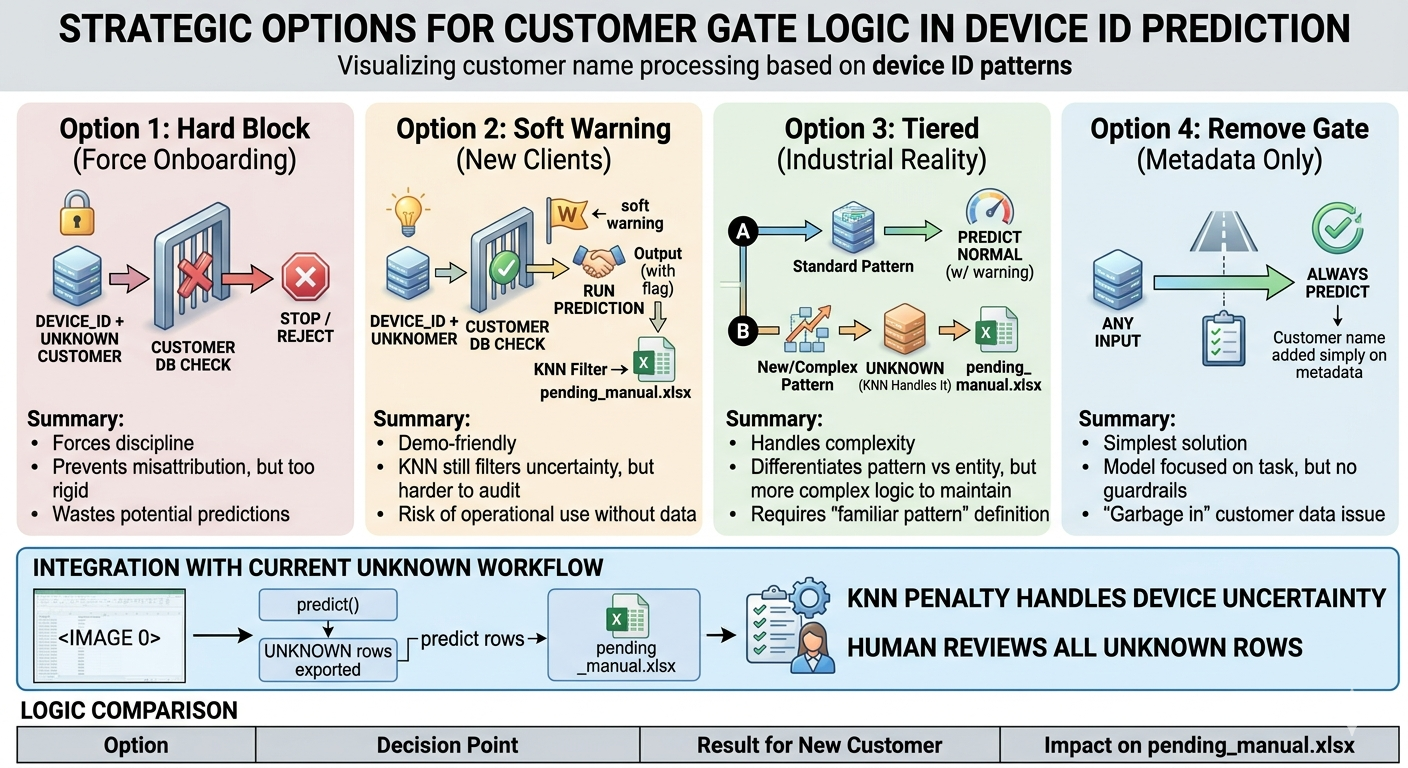
